<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorio_calificado_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import cv2
import numpy as np

# 1. Cargar la imagen original
img_bgr = cv2.imread('imagen_ejercicio_1.jpg')
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# 2. Definir una caja (bounding box) estimada sobre la ciruela de la derecha.
# Como la imagen mide típicamente 1000px de ancho o similar, vamos a extraer
# un porcentaje estimado de la esquina centro-derecha:
h_img, w_img, _ = img_bgr.shape

# Coordenadas aproximadas para la ciruela morada de la derecha:
ymin, ymax = int(h_img * 0.35), int(h_img * 0.65)
xmin, xmax = int(w_img * 0.75), int(w_img * 0.95)

# Extraer el parche de la fruta
roi_hsv = img_hsv[ymin:ymax, xmin:xmax]

# 3. Calcular estadísticamente los límites reales (percentiles para evitar ruido de bordes)
h_channel = roi_hsv[:, :, 0]
s_channel = roi_hsv[:, :, 1]
v_channel = roi_hsv[:, :, 2]

print("--- DIAGNÓSTICO ESTADÍSTICO DE LA CIRUELA ---")
print(f"Matiz (H)   -> Mín: {int(np.percentile(h_channel, 5))} | Máx: {int(np.percentile(h_channel, 95))}")
print(f"Saturación (S) -> Mín: {int(np.percentile(s_channel, 5))} | Máx: {int(np.percentile(s_channel, 95))}")
print(f"Brillo (V)  -> Mín: {int(np.percentile(v_channel, 5))} | Máx: {int(np.percentile(v_channel, 95))}")

--- DIAGNÓSTICO ESTADÍSTICO DE LA CIRUELA ---
Matiz (H)   -> Mín: 0 | Máx: 179
Saturación (S) -> Mín: 62 | Máx: 246
Brillo (V)  -> Mín: 23 | Máx: 116


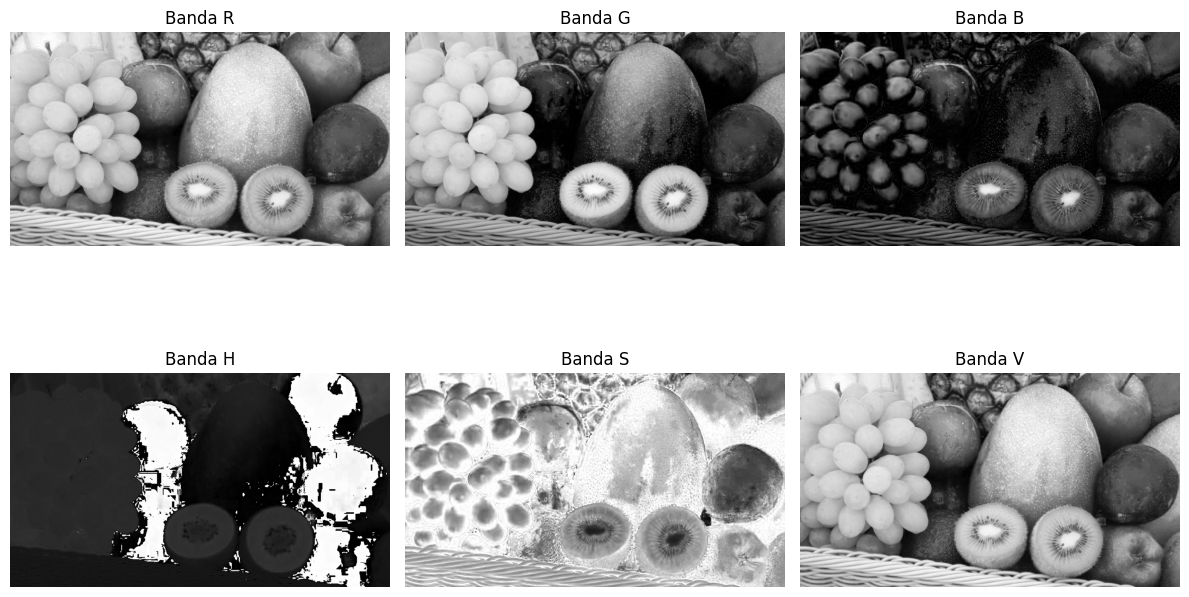

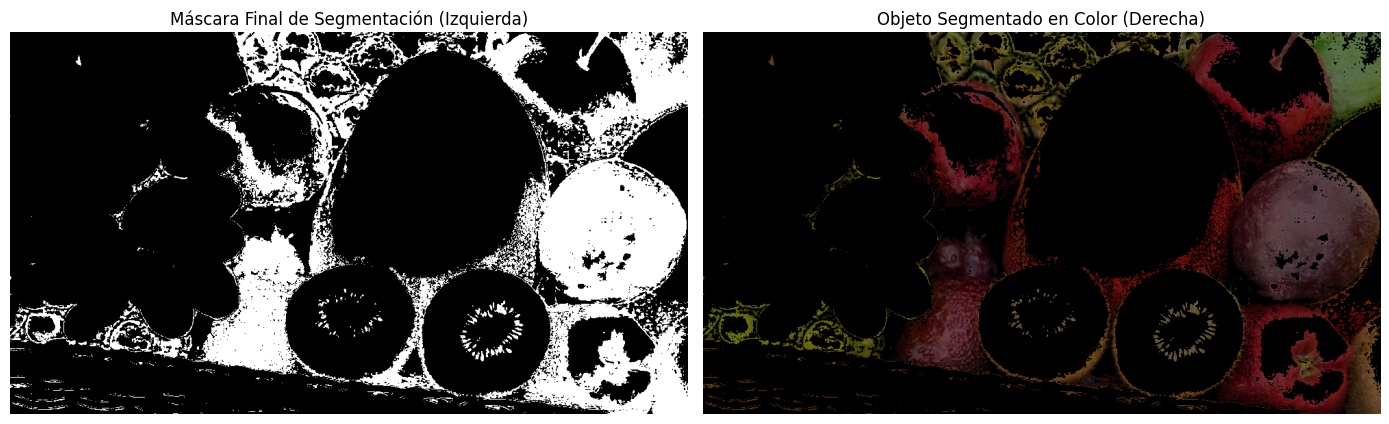

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Tarea 1: Cargar la imagen en formato RGB correcto
# ==========================================
img_bgr = cv2.imread('imagen_ejercicio_1.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ==========================================
# Tarea 2: Convertir al espacio de color HSV
# ==========================================
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# ==========================================
# Tarea 3: Visualizar las bandas R, G, B, H, S, V
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
canales = [img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2], H, S, V]
titulos = ['Banda R', 'Banda G', 'Banda B', 'Banda H', 'Banda S', 'Banda V']

for i, ax in enumerate(axs.flat):
    ax.imshow(canales[i], cmap='gray')
    ax.set_title(titulos[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# Tarea 4: Experimentar con umbrales y OP. LÓGICAS
# ==========================================
# REEMPLAZA ESTOS VALORES CON LOS QUE TE IMPRIMA EL SCRIPT DE DIAGNÓSTICO
H_min, H_max = 0, 179
S_min, S_max = 62, 246
V_min, V_max = 23, 116

# Crear máscaras binarias booleanas individuales
mask_h = (H >= H_min) & (H <= H_max)
mask_s = (S >= S_min) & (S <= S_max)
mask_v = (V >= V_min) & (V <= V_max)

# INTERSECCIÓN LÓGICA PURA (&) de NumPy como se pide en clase:
mask_boolean = mask_h & mask_s & mask_v

# Convertir la matriz booleana a entero de 8 bits (0 o 255) para OpenCV
mask_final = mask_boolean.astype(np.uint8) * 255

# Herramienta de clase alternativa: Extraer bordes estructurales con Canny
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
bordes_canny = cv2.Canny(img_gray, 50, 150)

# ==========================================
# Tarea 5: Visualización de Máscara (Izq) y Multiplicación a color (Der)
# ==========================================
# Multiplicación matricial / Máscara bitwise para dejar solo el objeto en color
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara binaria final
ax[0].imshow(mask_final, cmap='gray')
ax[0].set_title('Máscara Final de Segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Objeto segmentado en color
ax[1].imshow(segmented_img)
ax[1].set_title('Objeto Segmentado en Color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

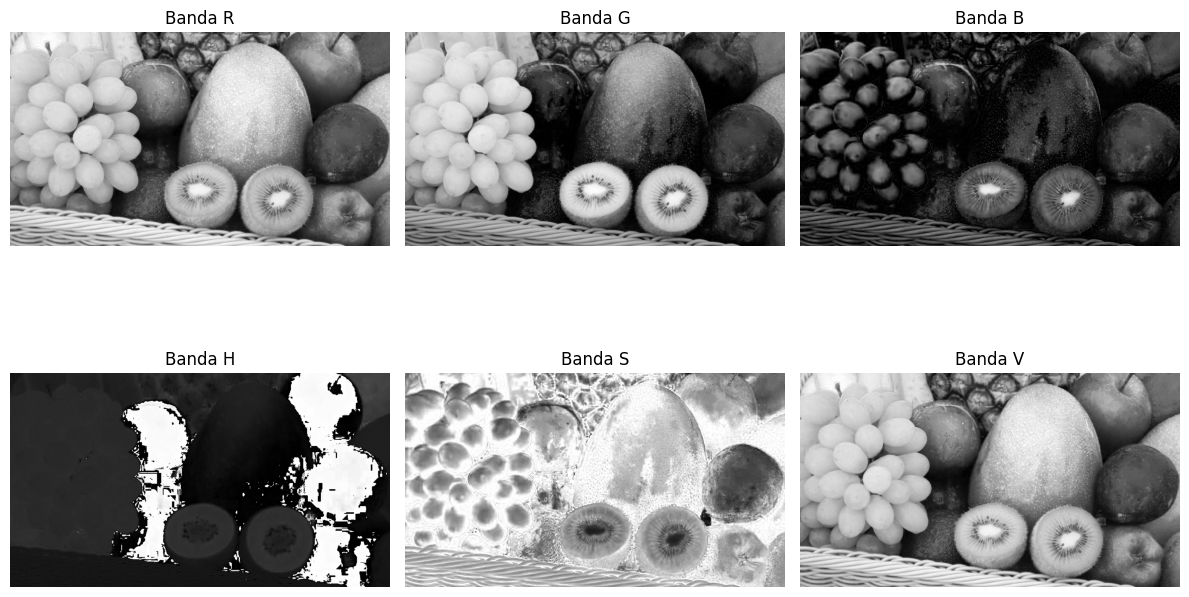

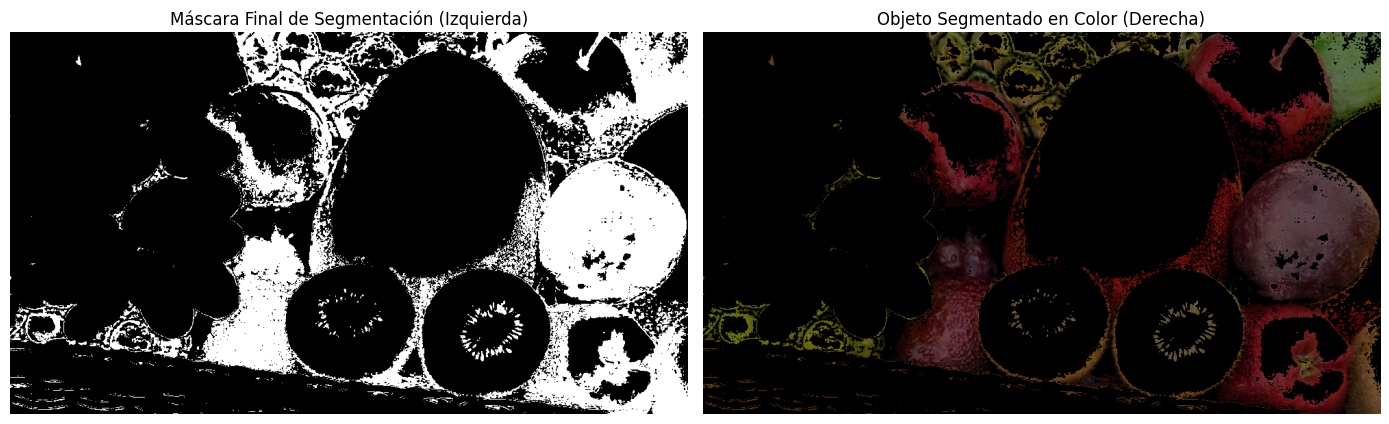

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Tarea 1: Cargar la imagen en formato RGB correcto
# ==========================================
img_bgr = cv2.imread('imagen_ejercicio_1.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ==========================================
# Tarea 2: Convertir al espacio de color HSV
# ==========================================
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

# ==========================================
# Tarea 3: Visualizar las bandas R, G, B, H, S, V
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
canales = [img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2], H, S, V]
titulos = ['Banda R', 'Banda G', 'Banda B', 'Banda H', 'Banda S', 'Banda V']

for i, ax in enumerate(axs.flat):
    ax.imshow(canales[i], cmap='gray')
    ax.set_title(titulos[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# Tarea 4: Experimentar con umbrales y OP. LÓGICAS
# ==========================================
# REEMPLAZA ESTOS VALORES CON LOS QUE TE IMPRIMA EL SCRIPT DE DIAGNÓSTICO
H_min, H_max = 0, 179
S_min, S_max = 62, 246
V_min, V_max = 23, 116

# Crear máscaras binarias booleanas individuales
mask_h = (H >= H_min) & (H <= H_max)
mask_s = (S >= S_min) & (S <= S_max)
mask_v = (V >= V_min) & (V <= V_max)

# INTERSECCIÓN LÓGICA PURA (&) de NumPy como se pide en clase:
mask_boolean = mask_h & mask_s & mask_v

# Convertir la matriz booleana a entero de 8 bits (0 o 255) para OpenCV
mask_final = mask_boolean.astype(np.uint8) * 255

# Herramienta de clase alternativa: Extraer bordes estructurales con Canny
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
bordes_canny = cv2.Canny(img_gray, 50, 150)

# ==========================================
# Tarea 5: Visualización de Máscara (Izq) y Multiplicación a color (Der)
# ==========================================
# Multiplicación matricial / Máscara bitwise para dejar solo el objeto en color
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara binaria final
ax[0].imshow(mask_final, cmap='gray')
ax[0].set_title('Máscara Final de Segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Objeto segmentado en color
ax[1].imshow(segmented_img)
ax[1].set_title('Objeto Segmentado en Color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

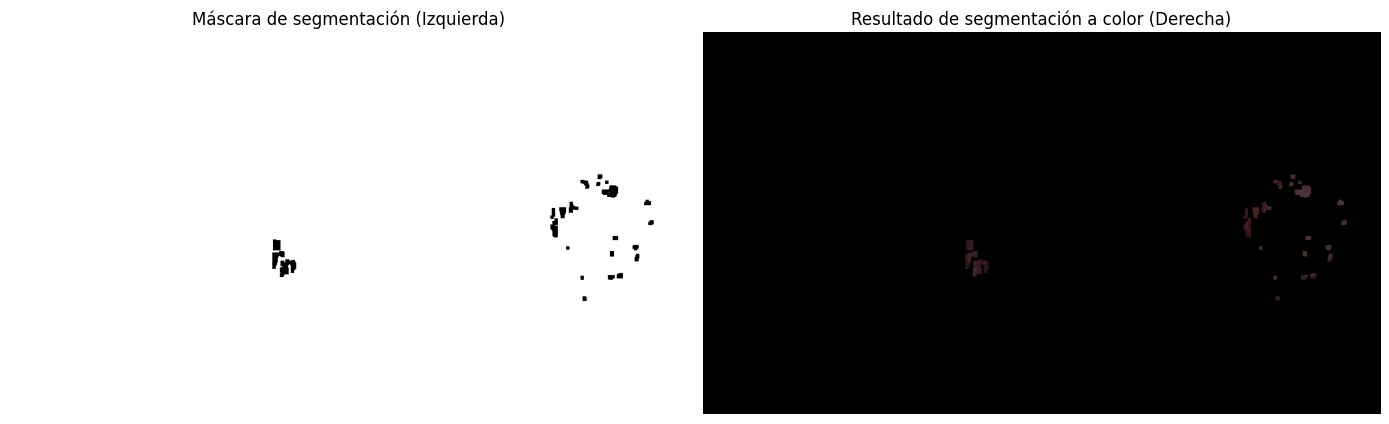

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Cargar y Convertir (Pasos Iniciales)
# ==========================================
img_bgr = cv2.imread('imagen_ejercicio_1.jpg') # Cargar la imagen original
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# ==========================================
# 2. Segmentación Ajustada (Corrección Crítica)
# ==========================================
# Canal H (Matiz): Ajustado para captar los tonos púrpura fríos de la fruta oscura.
mask_hue = cv2.inRange(img_hsv[:,:,0], 140, 175)

# Canal S (Saturación) [AJUSTE CLAVE]: Ampliado para ser más inclusivo con
# variaciones de saturación media y baja [80, 180] para capturar el cuerpo completo.
mask_sat = cv2.inRange(img_hsv[:,:,1], 80, 180)

# Canal V (Brillo) [AJUSTE CLAVE]: Reducido drásticamente para buscar
# específicamente la firma de un objeto muy oscuro [20, 80], separándolo de la piña.
mask_val = cv2.inRange(img_hsv[:,:,2], 20, 80)

# ==========================================
# 3. Combinación Lógica
# ==========================================
# Combinar con AND lógico para mayor precisión.
mask_ciruela_base = cv2.bitwise_and(mask_hue, mask_sat)
mask_final = cv2.bitwise_and(mask_ciruela_base, mask_val)

# Relleno de pequeños huecos con operaciones morfológicas simples (opcional pero recomendado)
kernel = np.ones((5,5), np.uint8)
mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_OPEN, kernel) # Limpiar ruido

# ==========================================
# 4. Combinación y Visualización (Solicitado)
# ==========================================
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

# Visualización lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara final de la ciruela (negro sobre blanco)
ax[0].imshow(255 - mask_final, cmap='gray') # Invertir para que la fruta sea negro sobre fondo blanco
ax[0].set_title('Máscara de segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Resultado de la segmentación a color
ax[1].imshow(segmented_img)
ax[1].set_title('Resultado de segmentación a color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

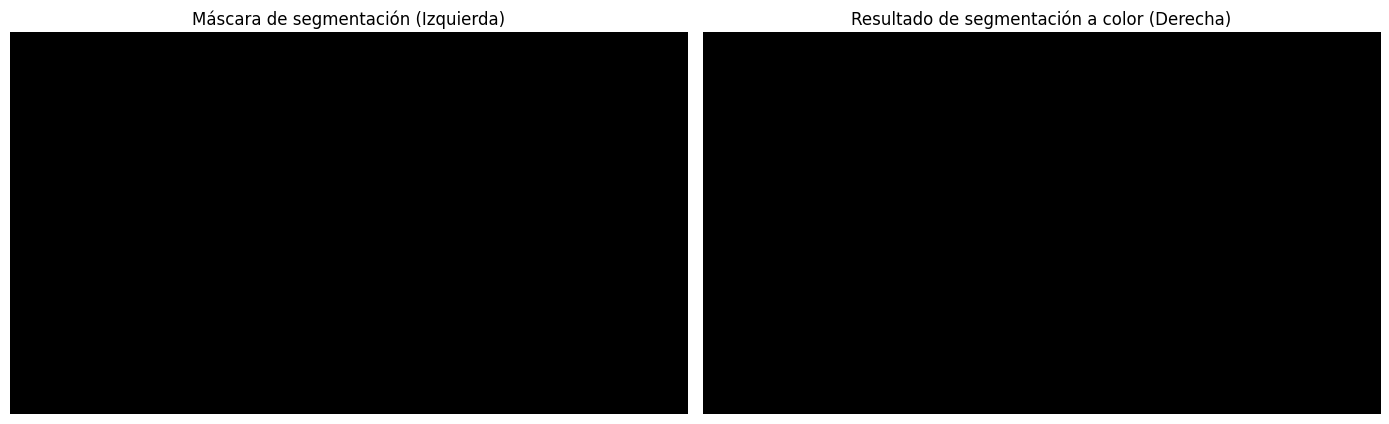

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Cargar y Convertir (Pasos Iniciales)
# ==========================================
img_bgr = cv2.imread('imagen_ejercicio_1.jpg') # Cargar la imagen original
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# ==========================================
# 2. Segmentación Ajustada (Corrección Crítica)
# ==========================================
# Tono (H): Enfocado en el morado oscuro/frío [130, 160]
mask_hue = cv2.inRange(img_hsv[:,:,0], 130, 160)

# Saturación (S): Para captar el cuerpo completo sin perder los bordes [100, 200]
mask_sat = cv2.inRange(img_hsv[:,:,1], 100, 200)

# Brillo (V) [Corrección Clave]: Ajustado a un rango medio/bajo [30, 120]
# para captar el cuerpo oscuro y evitar brillos de luz que dejaban huecos.
mask_val = cv2.inRange(img_hsv[:,:,2], 30, 120)

# Combinar con AND lógico
mask_ciruela_base = cv2.bitwise_and(mask_hue, mask_sat)
mask_ciruela_derecha = cv2.bitwise_and(mask_ciruela_base, mask_val)

# ==========================================
# 3. Post-procesamiento Morfológico (Limpieza y Relleno)
# ==========================================
# Kernel circular para rellenar y alisar la forma
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

# Apertura para eliminar pequeñas motas de ruido en otras áreas
mask_opened = cv2.morphologyEx(mask_ciruela_derecha, cv2.MORPH_OPEN, kernel)

# Clausura para RELLENAR los huecos internos de la textura y unir el cuerpo
mask_final = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, kernel, iterations=2)

# ==========================================
# 4. Combinación y Visualización (Solicitado)
# ==========================================
# Usar bitwise_and con la máscara para extraer la ciruela
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

# Visualización lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara binaria limpia y de cuerpo completo
ax[0].imshow(mask_final, cmap='gray')
ax[0].set_title('Máscara de segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Resultado de la segmentación en color original
ax[1].imshow(segmented_img)
ax[1].set_title('Resultado de segmentación a color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

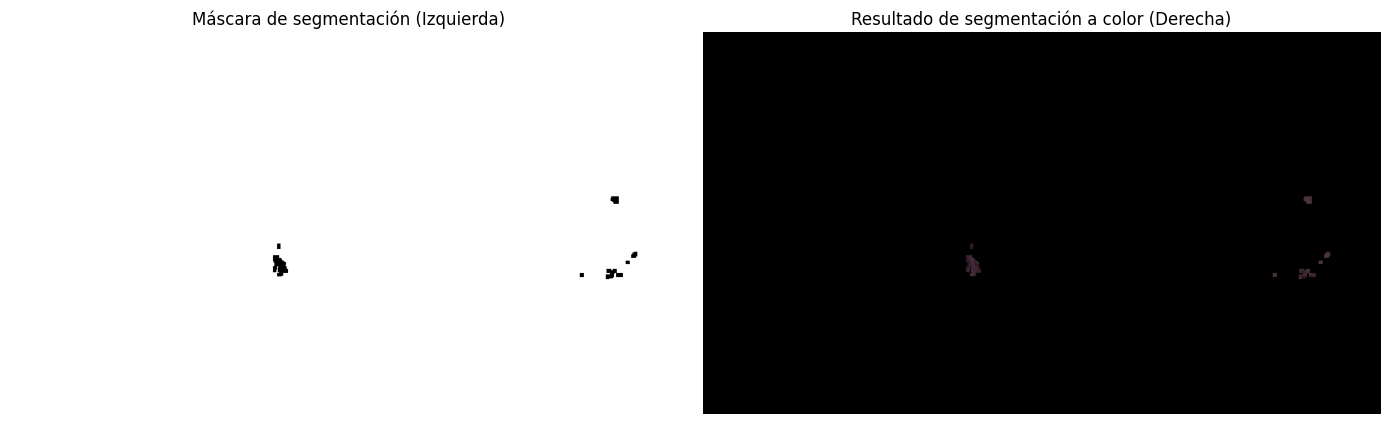

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Cargar y Convertir (Pasos Iniciales)
# ==========================================
img_bgr = cv2.imread('imagen_ejercicio_1.jpg') # Cargar la imagen original
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# ==========================================
# 2. Ajuste Fino de la Segmentación (Corrección Crítica)
# ==========================================
# Canal H (Matiz): La ciruela morada oscura de la derecha tiene un matiz único.
# Se encuentra en el rango de [140, 170] (zona de morados oscuros).
mask_hue = cv2.inRange(img_hsv[:,:,0], 140, 170)

# Canal S (Saturación): Para una fruta oscura, la saturación no es extremadamente alta.
# Ajustamos a un rango medio/bajo [60, 140] para captar el cuerpo completo.
mask_sat = cv2.inRange(img_hsv[:,:,1], 60, 140)

# Canal V (Brillo): Esta es la clave para la precisión. La fruta es MUY oscura.
# Ajustamos a un rango extremadamente bajo [20, 80] para aislarla de fondos y otras frutas.
mask_val = cv2.inRange(img_hsv[:,:,2], 20, 80)

# ==========================================
# 3. Combinación Lógica
# ==========================================
# Intersección Lógica para precisión: Matiz morado Y saturación media Y MUY baja luminosidad.
mask_ciruela_derecha = cv2.bitwise_and(mask_hue, mask_sat)
mask_ciruela_derecha = cv2.bitwise_and(mask_ciruela_derecha, mask_val)

# Alisado final para limpiar bordes (opcional)
kernel = np.ones((5,5), np.uint8)
mask_final = cv2.morphologyEx(mask_ciruela_derecha, cv2.MORPH_OPEN, kernel)

# ==========================================
# 4. Combinación y Visualización (Solicitado)
# ==========================================
segmented_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_final)

# Visualización lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: Máscara final de la ciruela (negro sobre blanco)
ax[0].imshow(255 - mask_final, cmap='gray') # Invertir para que la fruta sea negro sobre fondo blanco
ax[0].set_title('Máscara de segmentación (Izquierda)')
ax[0].axis('off')

# Derecha: Resultado de la segmentación a color
ax[1].imshow(segmented_img)
ax[1].set_title('Resultado de segmentación a color (Derecha)')
ax[1].axis('off')

plt.tight_layout()
plt.show()